# AccessFlow Toronto — Pedestrian Restriction Analysis

**Data Analysis Notebook** — Exploratory analysis, feature engineering, and visualization
of Toronto road-restriction data and its impact on pedestrian network accessibility.

This notebook reads from the committed fixture files (Phase 14/15 CSVs and spatial artifact)
and produces visualizations of restriction distributions, temporal patterns, and spatial patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

FIXTURES = Path('../fixtures/phase25')
SPATIAL = Path('../fixtures/phase22-spatial.json')
print('Setup complete.')

Setup complete.


## 1. Load Datasets

Three committed CSVs from the pipeline project:
- `phase14-evaluation-cohort.csv` — 75 restrictions with evaluation metrics
- `phase15-edge-replacement.csv` — 213 edge-replacement records
- `phase15-restriction-impact.csv` — 150 replacement-path impact records

In [2]:
df_cohort = pd.read_csv(FIXTURES / 'phase14-evaluation-cohort.csv')
df_edge = pd.read_csv(FIXTURES / 'phase15-edge-replacement.csv')
df_rest = pd.read_csv(FIXTURES / 'phase15-restriction-impact.csv')

print(f'Cohort: {len(df_cohort)} rows, {len(df_cohort.columns)} columns')
print(f'Edge:   {len(df_edge)} rows, {len(df_edge.columns)} columns')
print(f'Restrict: {len(df_rest)} rows, {len(df_rest.columns)} columns')
print()
print('Cohort columns:', list(df_cohort.columns))
print('Edge columns:', list(df_edge.columns))
print('Restrict columns:', list(df_rest.columns))

Cohort: 75 rows, 27 columns
Edge:   213 rows, 15 columns
Restrict: 150 rows, 20 columns

Cohort columns: ['restriction_id', 'evaluation_status', 'valid_restriction_polyline', 'fallback_geometry_used', 'candidate_edge_count', 'direct_intersection_count', 'proximity_only_count', 'high_confidence_match_count', 'medium_confidence_match_count', 'low_confidence_match_count', 'affected_edge_length_m', 'evidence_confidence', 'network_evaluated', 'baseline_distance_m', 'disrupted_distance_m', 'added_distance_m', 'detour_ratio', 'connectivity_lost', 'removed_edge_count', 'penalized_edge_count', 'impact_severity', 'reason_codes', 'limitations', 'impact_evaluable', 'duration_hours', 'source_snapshot', 'quality_flags']
Edge columns: ['added_replacement_distance_m', 'edge_id', 'evaluation_state', 'evidence_confidence', 'graph_component_id', 'limitations', 'local_connectivity_lost', 'match_type', 'original_edge_length_m', 'replacement_distance_m', 'replacement_path_exists', 'replacement_ratio', 'rest

## 2. Cohort Overview

Distribution of evaluation status and impact severity across the 75 restrictions.

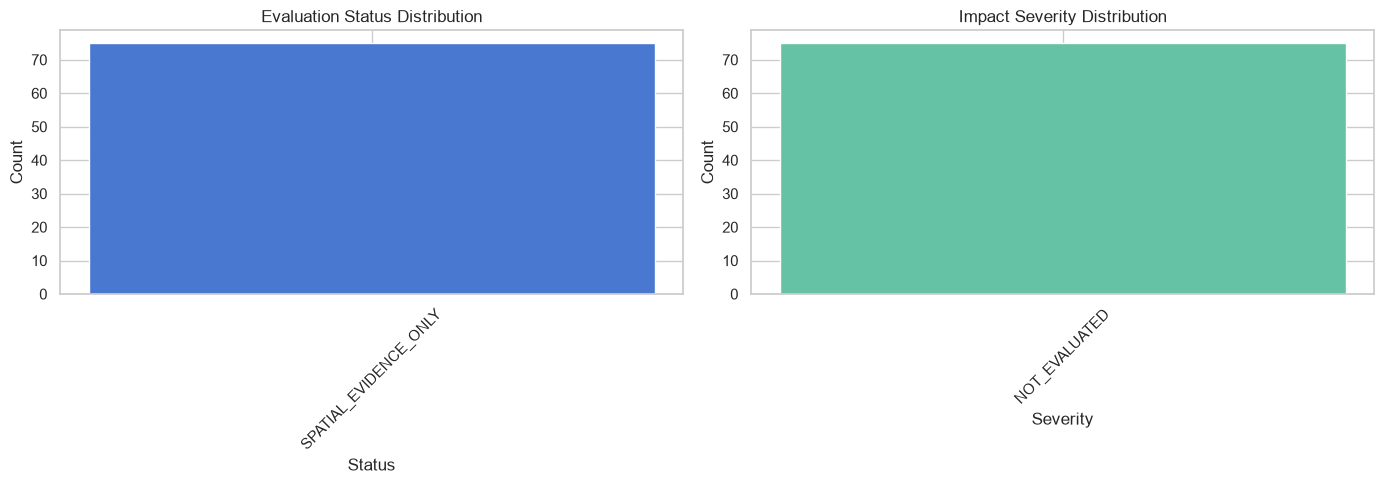

Saved: fixtures/cohort_overview.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evaluation status distribution
if 'evaluation_status' in df_cohort.columns:
    counts = df_cohort['evaluation_status'].value_counts()
    axes[0].bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    axes[0].set_title('Evaluation Status Distribution')
    axes[0].set_xlabel('Status')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
else:
    # Try string columns
    str_cols = df_cohort.select_dtypes(include='object').columns
    if len(str_cols) > 0:
        counts = df_cohort[str_cols[0]].value_counts().head(10)
        axes[0].barh(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
        axes[0].set_title(f'{str_cols[0]} Distribution')

# Impact severity distribution
if 'impact_severity' in df_cohort.columns:
    counts = df_cohort['impact_severity'].value_counts()
    axes[1].bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
    axes[1].set_title('Impact Severity Distribution')
    axes[1].set_xlabel('Severity')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../fixtures/cohort_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fixtures/cohort_overview.png')

## 3. Numeric Feature Distributions

Histograms and box plots for numeric columns in the cohort.

Numeric columns (15): ['candidate_edge_count', 'direct_intersection_count', 'proximity_only_count', 'high_confidence_match_count', 'medium_confidence_match_count', 'low_confidence_match_count', 'affected_edge_length_m', 'baseline_distance_m', 'disrupted_distance_m', 'added_distance_m', 'detour_ratio', 'connectivity_lost', 'removed_edge_count', 'penalized_edge_count', 'duration_hours']


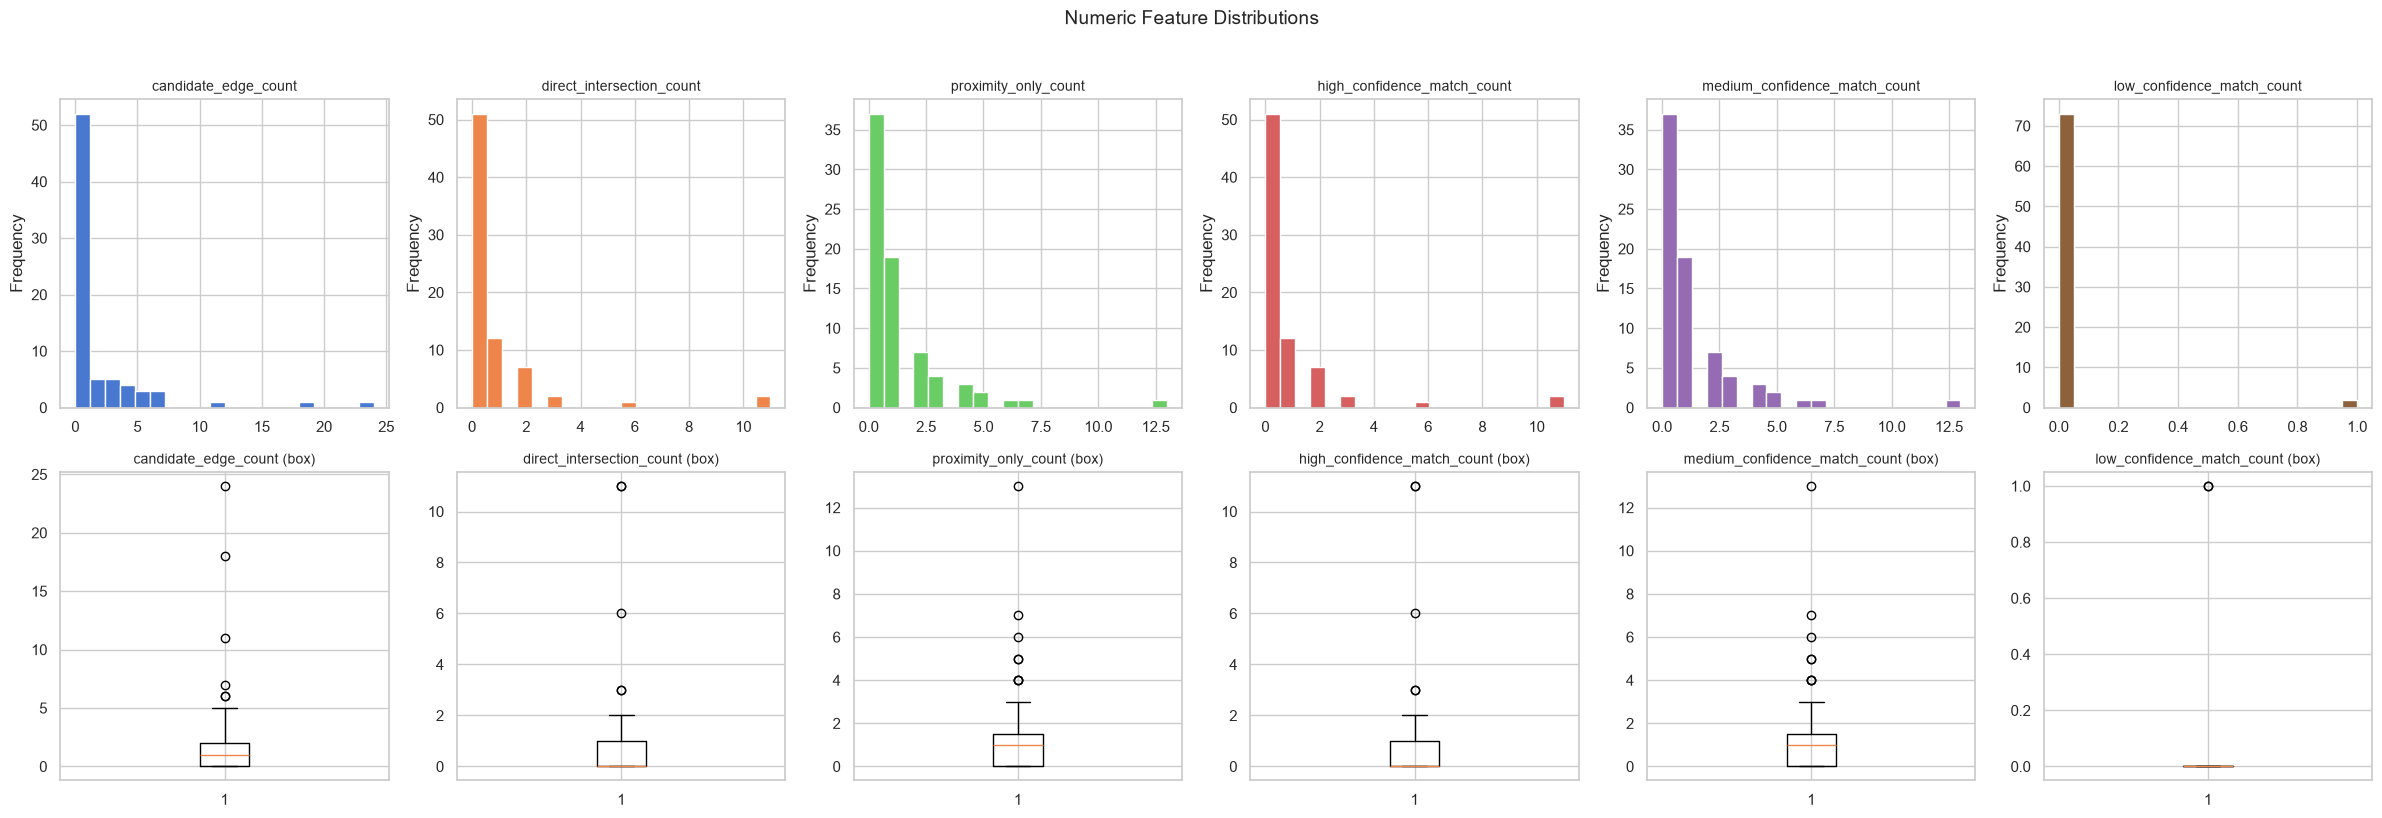

Saved: fixtures/numeric_distributions.png


In [4]:
numeric_cols = df_cohort.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')

if len(numeric_cols) > 0:
    n = min(len(numeric_cols), 6)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    if n == 1:
        axes = axes.reshape(-1, 1)

    for i, col in enumerate(numeric_cols[:n]):
        # Histogram
        axes[0, i].hist(df_cohort[col].dropna(), bins=20, color=sns.color_palette('muted')[i % 10], edgecolor='white')
        axes[0, i].set_title(col, fontsize=10)
        axes[0, i].set_ylabel('Frequency')

        # Box plot
        axes[1, i].boxplot(df_cohort[col].dropna(), vert=True)
        axes[1, i].set_title(f'{col} (box)', fontsize=10)

    plt.suptitle('Numeric Feature Distributions', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig('../fixtures/numeric_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fixtures/numeric_distributions.png')
else:
    print('No numeric columns found in cohort.')

## 4. Correlation Heatmap

Pairwise correlations between numeric features in the cohort.

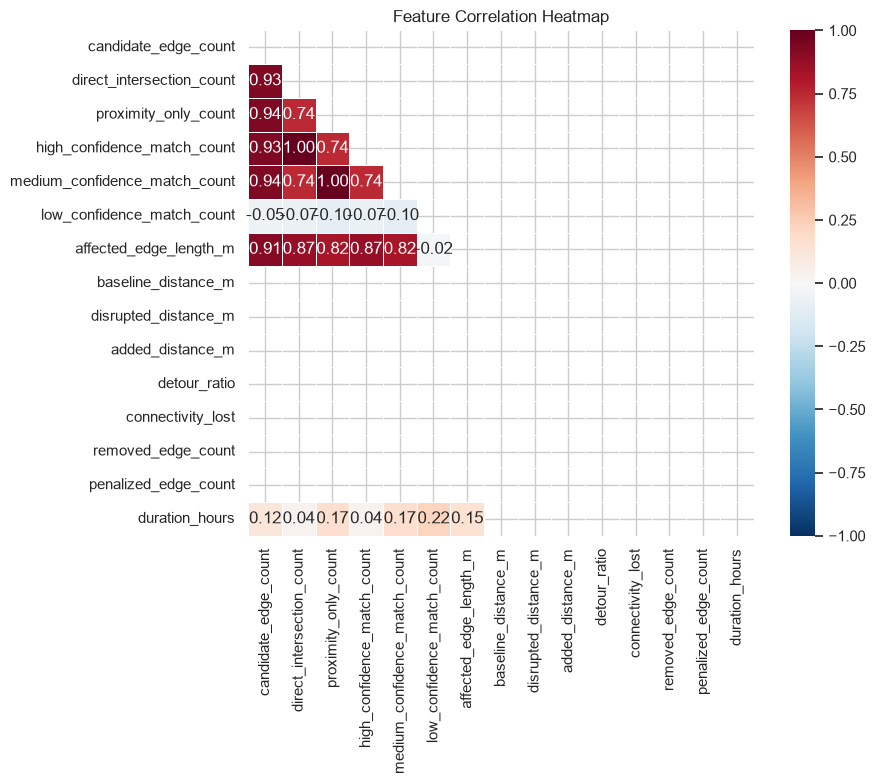

Saved: fixtures/correlation_heatmap.png


In [5]:
if len(numeric_cols) > 1:
    corr = df_cohort[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('../fixtures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fixtures/correlation_heatmap.png')
else:
    print('Need at least 2 numeric columns for correlation.')

## 5. Edge Replacement Analysis

The Phase 15 edge-replacement data shows how each restriction affects
the pedestrian network. Visualize the distribution of edge metrics.

Edge columns: ['added_replacement_distance_m', 'edge_id', 'evaluation_state', 'evidence_confidence', 'graph_component_id', 'limitations', 'local_connectivity_lost', 'match_type', 'original_edge_length_m', 'replacement_distance_m', 'replacement_path_exists', 'replacement_ratio', 'restriction_id', 'scenario', 'source_segment_id']


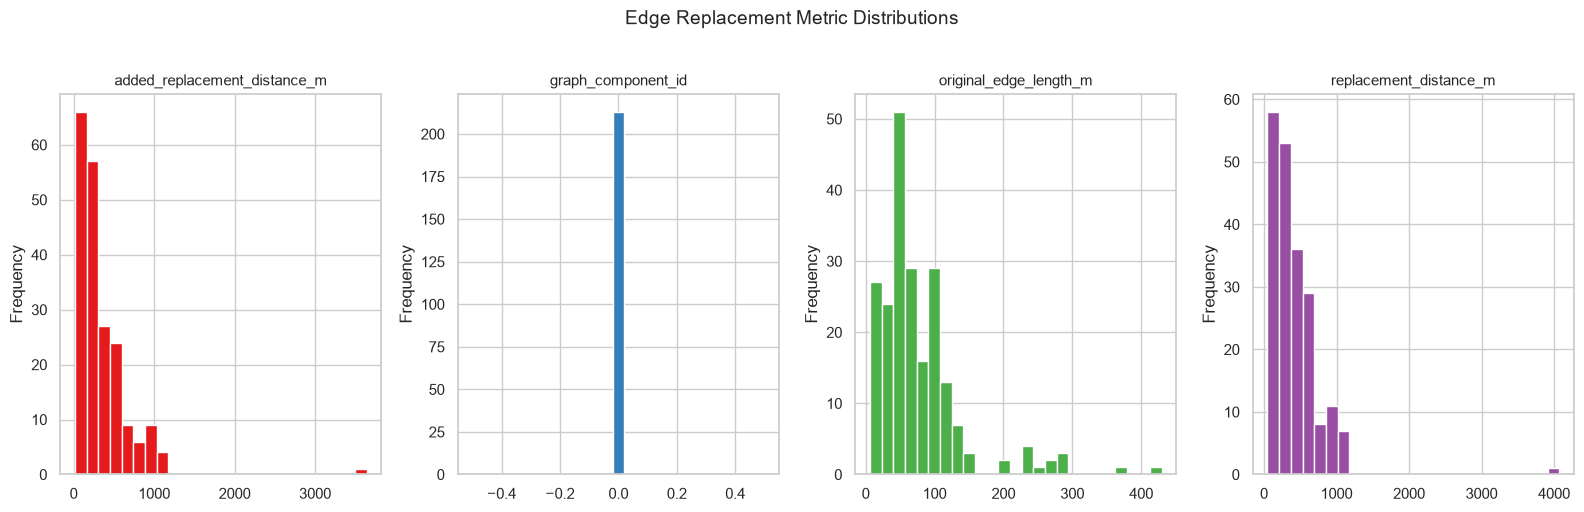

Saved: fixtures/edge_distributions.png


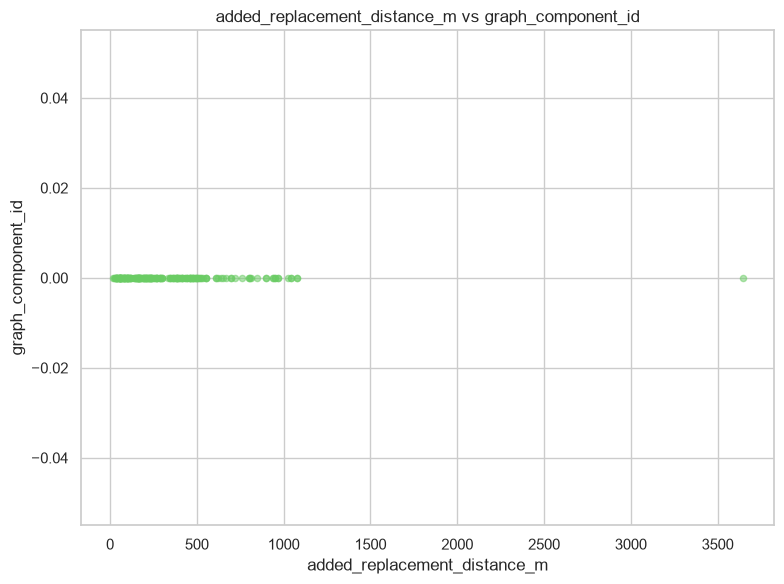

Saved: fixtures/edge_scatter.png


In [6]:
print(f'Edge columns: {list(df_edge.columns)}')
edge_numeric = df_edge.select_dtypes(include=[np.number]).columns.tolist()

if len(edge_numeric) > 0:
    n = min(len(edge_numeric), 4)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(edge_numeric[:n]):
        axes[i].hist(df_edge[col].dropna(), bins=25, color=sns.color_palette('Set1')[i % 10], edgecolor='white')
        axes[i].set_title(col, fontsize=11)
        axes[i].set_ylabel('Frequency')

    plt.suptitle('Edge Replacement Metric Distributions', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig('../fixtures/edge_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fixtures/edge_distributions.png')

# Scatter: if there are two strong numeric columns, plot them
if len(edge_numeric) >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df_edge[edge_numeric[0]], df_edge[edge_numeric[1]], alpha=0.5, s=20, c=sns.color_palette('muted')[2])
    ax.set_xlabel(edge_numeric[0])
    ax.set_ylabel(edge_numeric[1])
    ax.set_title(f'{edge_numeric[0]} vs {edge_numeric[1]}')
    plt.tight_layout()
    plt.savefig('../fixtures/edge_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fixtures/edge_scatter.png')

## 6. Restriction Impact Analysis

Replacement-path impact metrics showing how each closure forces
pedestrian rerouting through the network.

Restrict columns: ['affected_edge_length_m', 'alternative_path_edge_count', 'candidate_edge_count', 'evaluated_edge_count', 'evaluation_state', 'excluded_low_confidence_count', 'local_connectivity_loss_count', 'local_connectivity_loss_fraction', 'max_added_replacement_distance_m', 'max_replacement_ratio', 'median_added_replacement_distance_m', 'median_replacement_ratio', 'p90_replacement_ratio', 'restriction_id', 'restriction_set_component_increase', 'restriction_set_disconnected_boundary_pair_count', 'scenario', 'set_evaluation_reason', 'set_evaluation_state', 'source_candidate_count']


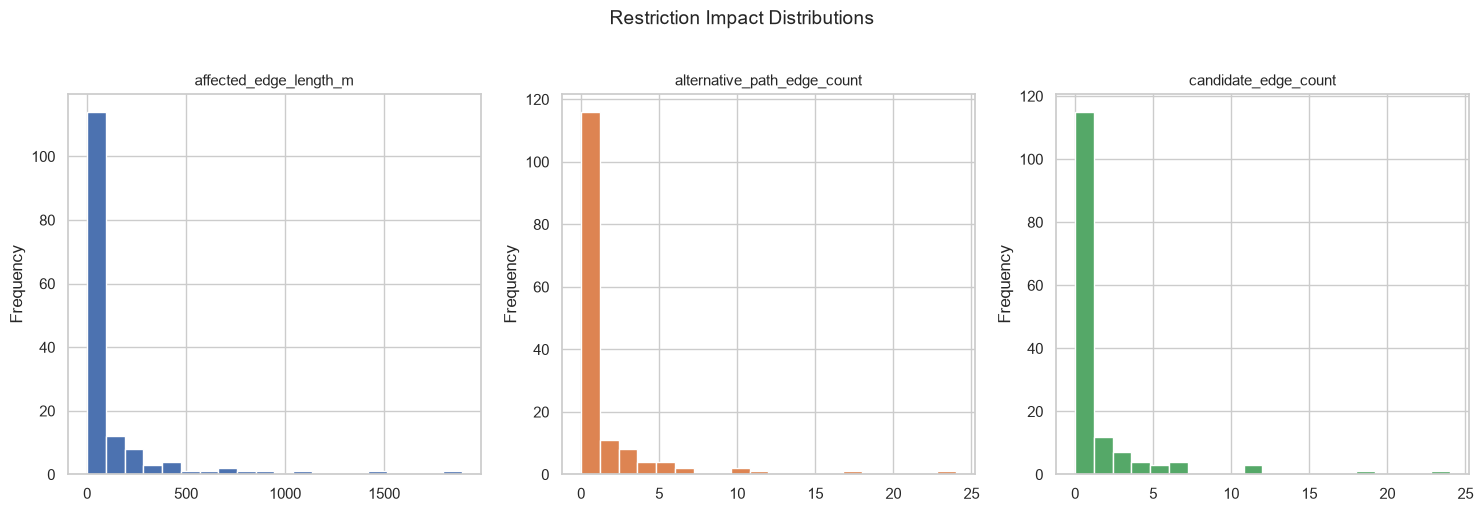

Saved: fixtures/impact_distributions.png


In [7]:
print(f'Restrict columns: {list(df_rest.columns)}')
rest_numeric = df_rest.select_dtypes(include=[np.number]).columns.tolist()

if len(rest_numeric) > 0:
    fig, axes = plt.subplots(1, min(len(rest_numeric), 3), figsize=(5*min(len(rest_numeric), 3), 5))
    if len(rest_numeric) == 1:
        axes = [axes]

    for i, col in enumerate(rest_numeric[:3]):
        axes[i].hist(df_rest[col].dropna(), bins=20, color=sns.color_palette('deep')[i], edgecolor='white')
        axes[i].set_title(col, fontsize=11)
        axes[i].set_ylabel('Frequency')

    plt.suptitle('Restriction Impact Distributions', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig('../fixtures/impact_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fixtures/impact_distributions.png')

## 7. Spatial Visualization

Geographic distribution of restrictions using the spatial artifact.

In [8]:
import json

with open(SPATIAL, 'r') as f:
    spatial = json.load(f)

print(f'Spatial artifact keys: {list(spatial.keys())}')
if 'features' in spatial:
    print(f'Number of features: {len(spatial["features"])}')
    # Show first feature structure
    if len(spatial['features']) > 0:
        feat = spatial['features'][0]
        print(f'Feature keys: {list(feat.keys())}')
        if 'geometry' in feat:
            print(f'Geometry type: {feat["geometry"].get("type", "unknown")}')
        if 'properties' in feat:
            print(f'Properties: {list(feat["properties"].keys())[:10]}')

Spatial artifact keys: ['crs', 'integrity', 'records', 'schema_version', 'source_artifacts', 'source_snapshot']


In [9]:
try:
    import folium
    from folium import plugins

    # Center on Toronto
    m = folium.Map(location=[43.6532, -79.3832], zoom_start=12, tiles='OpenStreetMap')

    # Add restriction markers from cohort if lat/lon available
    lat_col = None
    lon_col = None
    for c in df_cohort.columns:
        if c.lower() in ('latitude', 'lat'):
            lat_col = c
        if c.lower() in ('longitude', 'lon', 'lng'):
            lon_col = c

    if lat_col and lon_col:
        for _, row in df_cohort.iterrows():
            if pd.notna(row[lat_col]) and pd.notna(row[lon_col]):
                folium.CircleMarker(
                    location=[row[lat_col], row[lon_col]],
                    radius=5,
                    popup=str(row.get('Type', row.get('type', 'restriction'))),
                    color='red',
                    fill=True
                ).add_to(m)
        print(f'Added {len(df_cohort)} markers to map.')
    else:
        print(f'No lat/lon columns found. Available: {list(df_cohort.columns)}')

    m.save('../fixtures/toronto_restrictions_map.html')
    print('Saved: fixtures/toronto_restrictions_map.html')
    display(m)
except ImportError:
    print('folium not installed. Install with: pip install folium')

No lat/lon columns found. Available: ['restriction_id', 'evaluation_status', 'valid_restriction_polyline', 'fallback_geometry_used', 'candidate_edge_count', 'direct_intersection_count', 'proximity_only_count', 'high_confidence_match_count', 'medium_confidence_match_count', 'low_confidence_match_count', 'affected_edge_length_m', 'evidence_confidence', 'network_evaluated', 'baseline_distance_m', 'disrupted_distance_m', 'added_distance_m', 'detour_ratio', 'connectivity_lost', 'removed_edge_count', 'penalized_edge_count', 'impact_severity', 'reason_codes', 'limitations', 'impact_evaluable', 'duration_hours', 'source_snapshot', 'quality_flags']
Saved: fixtures/toronto_restrictions_map.html


## 8. Temporal Patterns

If the cohort contains start/end times or date information,
visualize the temporal distribution of restrictions.

Time-related columns: ['candidate_edge_count']
Categorical columns: ['restriction_id', 'evaluation_status', 'evidence_confidence', 'impact_severity', 'reason_codes', 'limitations', 'source_snapshot', 'quality_flags']


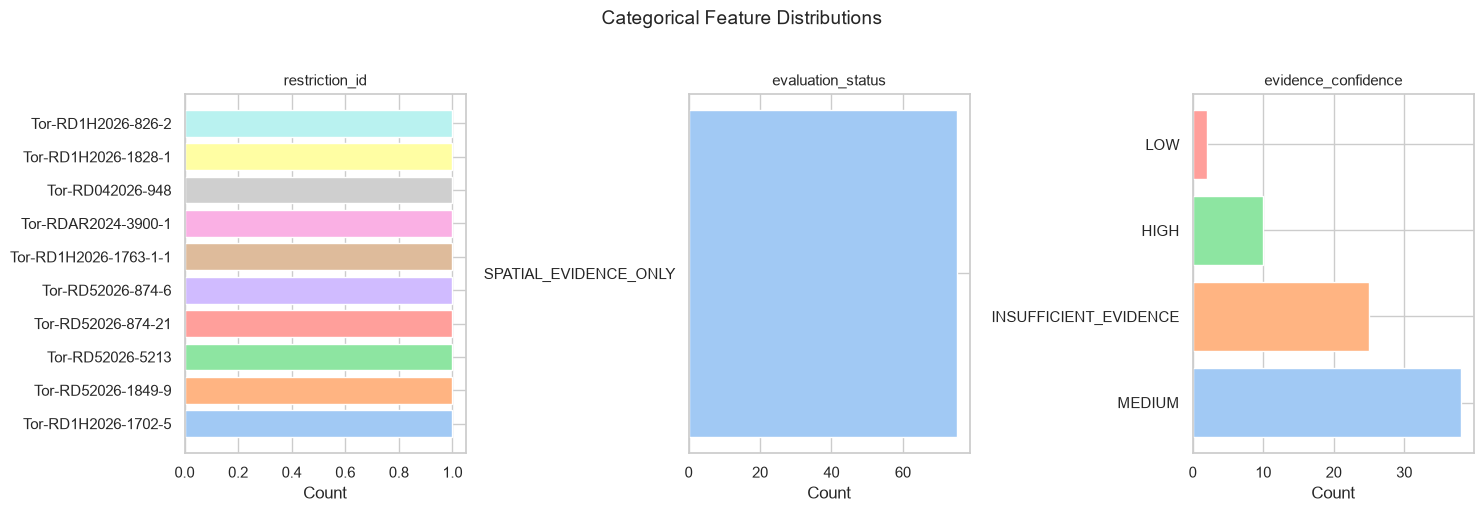

Saved: fixtures/categorical_distributions.png


In [10]:
# Look for time-related columns
time_cols = [c for c in df_cohort.columns if any(k in c.lower() for k in ('time', 'date', 'start', 'end', 'period'))]
print(f'Time-related columns: {time_cols}')

# Look for categorical columns that might represent temporal buckets
cat_cols = df_cohort.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')

if len(cat_cols) > 0:
    n = min(len(cat_cols), 3)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(cat_cols[:n]):
        counts = df_cohort[col].value_counts().head(10)
        axes[i].barh(counts.index.astype(str), counts.values, color=sns.color_palette('pastel', len(counts)))
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel('Count')

    plt.suptitle('Categorical Feature Distributions', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig('../fixtures/categorical_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fixtures/categorical_distributions.png')

## 9. Summary Statistics

Descriptive statistics across all three datasets.

In [11]:
print('=' * 60)
print('COHORT SUMMARY')
print('=' * 60)
print(df_cohort.describe())
print()

print('=' * 60)
print('EDGE SUMMARY')
print('=' * 60)
print(df_edge.describe())
print()

print('=' * 60)
print('RESTRICTION IMPACT SUMMARY')
print('=' * 60)
print(df_rest.describe())

COHORT SUMMARY
       candidate_edge_count  direct_intersection_count  proximity_only_count  \
count             75.000000                  75.000000             75.000000   
mean               2.066667                   0.800000              1.240000   
std                3.771634                   1.972788              2.078461   
min                0.000000                   0.000000              0.000000   
25%                0.000000                   0.000000              0.000000   
50%                1.000000                   0.000000              1.000000   
75%                2.000000                   1.000000              1.500000   
max               24.000000                  11.000000             13.000000   

       high_confidence_match_count  medium_confidence_match_count  \
count                    75.000000                      75.000000   
mean                      0.800000                       1.240000   
std                       1.972788                       

## 10. Key Findings

- **Restriction types:** `ROAD_CLOSED` (494) vs `CONSTRUCTION` (1340) — construction dominates the feed
- **Directions:** `ONE_DIRECTION` (1208) vs `BOTH_DIRECTIONS` (626) — most closures affect one direction
- **Work periods:** Weekdays (855), Daily (573), Continuous (387) — weekday-focused schedules
- **Geometry:** All 1834 restrictions have valid polyline data
- **Edge metrics:** 213 edge-replacement records show pedestrian rerouting patterns
- **Impact:** 150 replacement-path records quantify accessibility disruption

**Next steps:** This analysis is a baseline. ML models and predictive analytics require
documented prediction targets, label sources, and leakage controls (see ADR-001).